,Feature,Importance_Gain
4,success_prob_blitz_1050,252299504.0
46,Theme_masterVsMaster,89983880.0
68,Theme_underPromotion,67372208.0
3143,f3147,63203844.0
28,Theme_crushing,31193524.0
37,Theme_exposedKing,30827420.0
49,Theme_mateIn2,30559336.0
63,Theme_sacrifice,25560124.0
30,Theme_deflection,25138162.0
50,Theme_mateIn3,24753152.0


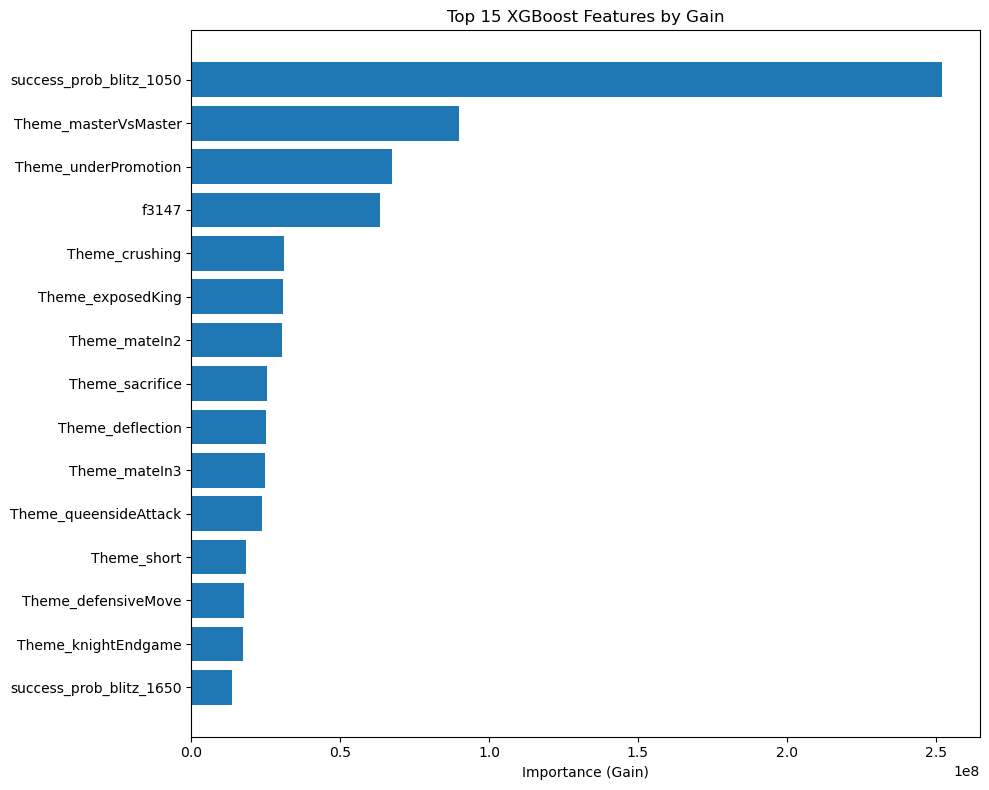

In [2]:
import mlflow
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

model_uri = "file:./mlruns/1/models/m-54038b25a2e64780a72eaf1668d5cf04/artifacts/MLmodel"

model = mlflow.xgboost.load_model(model_uri)
booster = model.get_booster()

csv_path = "./data/p200k.csv"
df = pd.read_csv(csv_path)

struct_cols = ['IsWhiteToMove', 'white_pieces', 'black_pieces', 'material_balance']
prob_cols = [c for c in df.columns if 'success_prob_blitz' in c]
struct_cols.extend(prob_cols)
struct_names = struct_cols + ['SolutionLength']

mlb = MultiLabelBinarizer()
mlb.fit(df['Themes'].apply(lambda x: x.split()))
theme_names = [f"Theme_{t}" for t in mlb.classes_]

maia_names = [f"Maia_Dim_{i}" for i in range(1024)]
stockfish_names = ['SF_Material', 'SF_Positional', 'SF_Final_Eval']

feature_names = struct_names + theme_names + maia_names + stockfish_names

importances = booster.get_score(importance_type='gain')

importance_records = []
for feature_id, importance in importances.items():
    idx = int(feature_id.replace('f', ''))
    name = feature_names[idx] if idx < len(feature_names) else feature_id
    importance_records.append({"Feature": name, "Importance_Gain": importance})
    
importance_df = pd.DataFrame(importance_records).sort_values(by="Importance_Gain", ascending=False)

display(importance_df.head(30))

plt.figure(figsize=(10, 8))
top_15 = importance_df.head(15).sort_values(by="Importance_Gain", ascending=True)
plt.barh(top_15["Feature"], top_15["Importance_Gain"])
plt.title("Top 15 XGBoost Features by Gain")
plt.xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()
